# ECON 5360 Tutorial 3
# Numerical Methods in MATLAB

### DING Minjie, Spring 2025

___________________________________________________________________________________________________________________________________________



In this tutorial, we will discuss basics and numerical methods in MATLAB, including:

* 1. Preparation for MATLAB
        * Set Working Directory
        * Clear Work
* 2. Basic of MATLAB
        * Data Type
        * Logical Operations
        * Define Functions
* 3. Graph
* 4. Matrix Manipulation and Calculation
* 5. Solve Nonlinear Equations/Root Finding
* 6. Numerical Optimization
* 7. Function Approximation with Interpolation
* 8. Discretization
* 9. Simulation

___________________________________________________________________________________________________________________________________________

# 1.1 Set Working Directory

We use "pwd" to get current working directory, and use "cd" to change working directory. 

When we work on MATLAB, we can also select working directory by right click with the mouse.

If we use MATLAB as kernel on other platform, these two code instructions are indispensable.


In [1]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

# 1.2 Clear Work

Before starting the work, we need to clean up the previous work.

In [2]:
clear all;  % Clears all variables from the workspace
close all;  % Closes all open figure windows
clc;        % Clears the Command Window

___________________________________________________________________________________________________________________________________________

# 2.1 Data Type

Here are three concepts used to store and manipulate data: Variable, Matrix, and Structure.

In [3]:
%% Variable
x = 10;          % Numeric variable
name = 'Alice';  % String variable
name

name = 'Alice'

In [4]:
%% Matrix(Vector)
matrix_y=[1,2,3; 4,5,6] % Create a 2x3 matrix

matrix_y(2,3)           % Access the element in the 2nd row, 3rd column
matrix_y(:,3)           % Access all elements in the 3rd column
matrix_y(2,:)           % Access all elements in the 2nd row

matrix_y(matrix_y>=3)   % Retrieve elements greater than or equal to 3
matrix_y(matrix_y>=3)=0 % Set elements greater than or equal to 3 to 0

matrix_y=zeros(3,2)     % Create a 3x2 matrix filled with zeros
matrix_y=ones(3,2)      % Create a 3x2 matrix filled with ones
matrix_y=NaN(3,2)       % Create a 3x2 matrix filled with NaN (Not a Number)

matrix_y = 2×3 double
     1     2     3
     4     5     6

ans = 6

ans = 2×1 double
     3
     6

ans = 1×3 double
     4     5     6

ans = 4×1 double
     4
     5
     3
     6

matrix_y = 2×3 double
     1     2     0
     0     0     0

matrix_y = 3×2 double
     0     0
     0     0
     0     0

matrix_y = 3×2 double
     1     1
     1     1
     1     1

matrix_y = 3×2 double
   NaN   NaN
   NaN   NaN
   NaN   NaN

In [5]:
%% Structure
person.name = 'Alice';  % Field 'name'
person.age = 30;        % Field 'age'
person.height = 5.5;    % Field 'height'
person

person = 包含以下字段的 struct:
      name: 'Alice'
       age: 30
    height: 5.5000

# 2.2 Logical Operations

The following code demonstrates various logical and relational operations in MATLAB.

In [6]:
2 >= 1         % Comparison: Is 2 greater than or equal to 1?
2 < 1          % Comparison: Is 2 less than 1?

1 & 0          % Logical AND operation: 1 & 0
1 | 0          % Logical OR operation: 1 | 0
~ 1            % Logical NOT operation: ~1
~ 0            % Logical NOT operation: ~0
1 ~= 2         % Comparison: Is 1 not equal to 2?
0 | 2          % Logical OR operation with numbers: 0 | 2

[1,2;3,4]>=2 & [1,2;3,4]<4
% Element-wise comparison with logical AND

ans = logical
   1

ans = logical
   0

ans = logical
   0

ans = logical
   1

ans = logical
   0

ans = logical
   1

ans = logical
   1

ans = logical
   1

ans = 2x2 logical 数组
   0   1
   1   0

# 2.3 Define Your Own Functions

We can define our own function in three ways:

1. Use @ operator
2. Define local function
3. Define function file outside of current file

## Use @ operator

Define a simple function directly.



In [7]:
f_square_1 = @(x) (x-1)^2;
f_square_1(3)

ans = 4

## Define local function

These are functions defined within a script. They are only accessible from within the file in which they are defined.

Ideal for organizing code within a single file, especially when the local function is only relevant to that file.



In [8]:
function output = f_square_2(x)    
    output = (x - 1)^2;
end

f_square_2(3)

ans = 4

Another example with a parameter. 

In [9]:
function [ output ] = f_square_2(x, c)
    output = (x-c)^2;
end

f_square_2(3,1)

ans = 4

## Define function file

This method genreate a separate .m files stored in current working directory. 

The filename must match the function name.

In Jupyter, we use "__%%file name.m__" to generate a separate .m files.


In [10]:
%%file f_square_3.m

function output = f_square_3(x)    
    output = (x - 1)^2;
end


File f_square_3.m created successfully.

In [11]:
f_square_3(3)

ans = 4

___________________________________________________________________________________________________________________________________________

# 3. Graphing

________________________________________________________________________________________________________________________________________

Here is a simple example. 

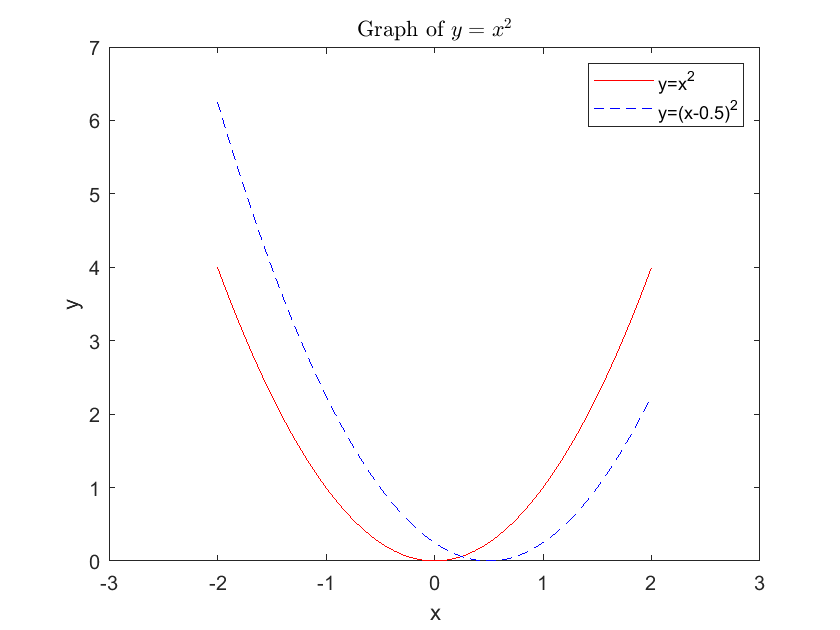

In [12]:
x_vec=(-2:0.01:2);
y_vec1=(x_vec).^2;
y_vec2=(x_vec-0.5).^2;

figure(1)
plot(x_vec, y_vec1, '-r', x_vec, y_vec2, '--b')     
% solid red line (-r) and dashed blue line (--b)
title('Graph of $y=x^{2}$','Interpreter','latex')
% use LaTeX interpreter for rendering the title text
xlabel('x')
ylabel('y')
legend('y=x^{2}','y=(x-0.5)^{2}') % adds a legend to the plot
xlim([-3, 3]);                    % Set the x-axis range

% saveas(gcf,'figure_1.pdf') 

We can also put subplots together.

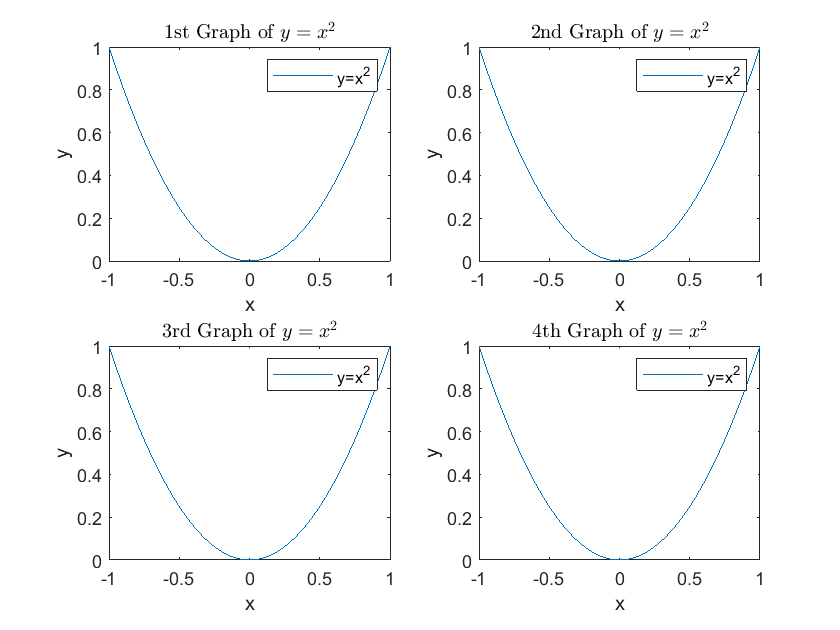

In [13]:
x_vec=(-1:0.01:1);
y_vec=x_vec.^2;

figure(2)
subplot(2,2,1)
plot(x_vec,y_vec)
title('1st Graph of $y=x^{2}$','Interpreter','latex')
xlabel('x')
ylabel('y')
legend('y=x^{2}')

subplot(2,2,2)
plot(x_vec,y_vec)
title('2nd Graph of $y=x^{2}$','Interpreter','latex')
xlabel('x')
ylabel('y')
legend('y=x^{2}')

subplot(2,2,3)
plot(x_vec,y_vec)
title('3rd Graph of $y=x^{2}$','Interpreter','latex')
xlabel('x')
ylabel('y')
legend('y=x^{2}')

subplot(2,2,4)
plot(x_vec,y_vec)
title('4th Graph of $y=x^{2}$','Interpreter','latex')
xlabel('x')
ylabel('y')
legend('y=x^{2}')

___________________________________________________________________________________________________________________________________________

# 4. Matrix Manipulation and Calculation

___________________________________________________________________________________________________________________________________________

We need to manipulate matrix. And here are some commonly used instructions.

| Function   | Purpose                            | Input Type         | Output Type           | Use Case                                      |
|------------|-----------------------------------|---------------------|-----------------------|-----------------------------------------------|
| `ndgrid`   | Generates N-dimensional grids     | Vectors             | Coordinate matrices    | Evaluating functions over multi-dimensional grids |
| `kron`     | Computes Kronecker product        | Matrices            | Larger matrix          | Constructing larger matrices                  |
| `reshape`  | Reshapes arrays                   | Array, new size     | Reshaped array         | Reorganizing data for processing              |
| `permute`  | Reorders dimensions of an array   | Array, new order    | Permuted array         | Changing orientation of multi-dimensional arrays |

## ndgrid

Input: N vectors representing the grid points along each dimension.

Output: N matrices containing the coordinates of the grid points.

Use Case: Useful for evaluating functions over a grid in multiple dimensions, such as surface plots or mesh grids.

In [14]:
a = 1:5;
b = 1:3;
[x, y] = ndgrid(a, b);
x
y

x = 5×3 double
     1     1     1
     2     2     2
     3     3     3
     4     4     4
     5     5     5

y = 5×3 double
     1     2     3
     1     2     3
     1     2     3
     1     2     3
     1     2     3

## kron

Useful for constructing larger matrices from smaller ones, particularly in linear algebra and systems theory.


In [15]:
A = [1 2; 3 4];
B = [0 5; 6 7];
C = kron(A, B);
A
B
C

A = 2×2 double
     1     2
     3     4

B = 2×2 double
     0     5
     6     7

C = 4×4 double
     0     5     0    10
     6     7    12    14
     0    15     0    20
    18    21    24    28

## reshape

Output a new array with the specified dimensions

In [16]:
A = 1:6;                % A = [1 2 3 4 5 6]
B = reshape(A, [2, 3]); % return a matrix with 2 rows and 3 columns
C = reshape(A, 2, 3);   % return a matrix with 2 rows and 3 columns
D = reshape(A, [], 3);  % return a matrix with 3 columns
A
B
C
D

A = 1×6 double
     1     2     3     4     5     6

B = 2×3 double
     1     3     5
     2     4     6

C = 2×3 double
     1     3     5
     2     4     6

D = 2×3 double
     1     3     5
     2     4     6

## permute

In [17]:
rng(100)
A = rand(2, 3, 4);          % A 3D array
B = permute(A, [3, 1, 2]);  
% dimension order change from [1,2,3] to [3,1,2]
% so (2,3,4) change to (4,2,3)
% 2rows*3column*4matrice ==> 4rows*2columns*3matrices
A
B

A = 
A(:,:,1) =

    0.5434    0.4245    0.0047
    0.2784    0.8448    0.1216


A(:,:,2) =

    0.6707    0.1367    0.8913
    0.8259    0.5751    0.2092


A(:,:,3) =

    0.1853    0.2197    0.8117
    0.1084    0.9786    0.1719


A(:,:,4) =

    0.8162    0.4317    0.8176
    0.2741    0.9400    0.3361

B = 
B(:,:,1) =

    0.5434    0.2784
    0.6707    0.8259
    0.1853    0.1084
    0.8162    0.2741


B(:,:,2) =

    0.4245    0.8448
    0.1367    0.5751
    0.2197    0.9786
    0.4317    0.9400


B(:,:,3) =

    0.0047    0.1216
    0.8913    0.2092
    0.8117    0.1719
    0.8176    0.3361

## spdiags

The spdiags function in MATLAB is used to create a sparse matrix from the diagonals specified in a given matrix. 

This is particularly useful when dealing with large matrices that are mostly sparse, as it allows for efficient storage and manipulation.



One of the basic syntax is:

    S = spdiags(Bin, d, m, n)

where:

    Bin: A matrix where each column represents a diagonal of the resulting sparse matrix.
    d: A vector specifying the locations of the diagonals. For example, 0 refers to the main diagonal, 1 refers to the first upper diagonal, -1 refers to the first lower diagonal, and so forth.
    m: The number of rows in the resulting sparse matrix.
    n: The number of columns in the resulting sparse matrix.

In [18]:
% Define the diagonals
Bin = [1 2 3;   % Main diagonal
       4 5 6;   % Upper diagonal
       7 8 9];  % Lower diagonal
Bin = Bin';

% Define the diagonal positions
d = [0, 1, -1]; % Main, Upper, and Lower

% Define the size of the sparse matrix
m = 3; % Number of rows
n = 3; % Number of columns

% Create the sparse matrix
S = spdiags(Bin, d, m, n);

% Display the sparse matrix
full(S)  % Convert to full matrix for display

ans = 3×3 double
     1     5     0
     7     2     6
     0     8     3

The main diagonal (0) contains values [1, 2, 3].

The first upper diagonal (1) contains values [4, 5].

The first lower diagonal (-1) contains values [7, 8].

This results in a sparse matrix where only the specified diagonals are filled, making it memory efficient for large matrices.

In [19]:
%% Change diagonal position

Bin = [1 2 3;   % Main diagonal
       4 5 6;   % Upper diagonal
       7 8 9];  % Lower diagonal
Bin = Bin';

% Define the diagonal positions
d = [0, 1]; % Main, Upper, and Lower

% Define the size of the sparse matrix
m = 3; % Number of rows
n = 3; % Number of columns

% Create the sparse matrix
S = spdiags(Bin, d, m, n);

% Display the sparse matrix
full(S)  % Convert to full matrix for display

ans = 3×3 double
     1     5     0
     0     2     6
     0     0     3

## speye

The speye function in MATLAB creates a sparse identity matrix. Sparse matrices are efficient for computations involving large matrices where most of the elements are zero, helping to save memory and speed up calculations.



speye(n) creates an n×n sparse identity matrix.

And identity matrix is a square matrix with ones on the diagonal and zeros elsewhere

In [20]:
% Create a 4x4 sparse identity matrix
n = 4;
I = speye(n);

% Display the matrix
disp(I);
I

   (1,1)        1
   (2,2)        1
   (3,3)        1
   (4,4)        1



I = 4x4 稀疏 double 矩阵 (4 个非零值)
   (1,1)        1
   (2,2)        1
   (3,3)        1
   (4,4)        1

## Backslash Operator `\` (mldivide) and Division Operator `/`

**`mldivide` (Backslash Operator `\`)**

Used to solve linear systems of equations of the form $Ax = b$, where $A$ is a matrix and $b$ is a vector or matrix.

The backslash operator computes $x = A \backslash b$, solving the equation $Ax = b$ for $x$.

Backslash Operator is high recommended for solving linear system. Division Operator is not preferred.

In [21]:
A = [1 2; 3 4];
b = [5; 6];
x = A \ b;  % Solves Ax = b
A
b
x

A = 2×2 double
     1     2
     3     4

b = 2×1 double
     5
     6

x = 2×1 double
   -4.0000
    4.5000

**Division Operator `/`**

Used for right division, which computes the solution to the equation $xA = b$ or equivalently $x = b / A$.

The division operator computes $x = b / A$. This is not a direct solution to a linear system but transforms the problem to the left side.

In [22]:
A = [1 2; 3 4];
b = [5 6; 7 8];
x = b / A;  % Solves xA = b
A
b
x

A = 2×2 double
     1     2
     3     4

b = 2×2 double
     5     6
     7     8

x = 2×2 double
   -1.0000    2.0000
   -2.0000    3.0000

## diff

Y = diff(X,n,dim) is the nth difference calculated along the dimension specified by dim. The dim input is a positive integer scalar.

In [23]:
X = [1 3 5;7 11 13;17 19 23];
Y1 = diff(X,1,1);
Y2 = diff(X,1,2);
X
Y1
Y2

X = 3×3 double
     1     3     5
     7    11    13
    17    19    23

Y1 = 2×3 double
     6     8     8
    10     8    10

Y2 = 3×2 double
     2     2
     4     2
     2     4

## repmat

repmat is a function in MATLAB that stands for "repeat matrix." It is used to replicate and tile an array (matrix) a specified number of times along each dimension

In [24]:
A = diag([100 200 300])
B = repmat(A,2,3)

A = 3×3 double
   100     0     0
     0   200     0
     0     0   300

B = 6×9 double
   100     0     0   100     0     0   100     0     0
     0   200     0     0   200     0     0   200     0
     0     0   300     0     0   300     0     0   300
   100     0     0   100     0     0   100     0     0
     0   200     0     0   200     0     0   200     0
     0     0   300     0     0   300     0     0   300

___________________________________________________________________________________________________________________________________________

# 5. Solve Nonlinear Equations

_____________________________________________________________________________________________________________________________________

## fsolve

fsolve is used to solve systems of nonlinear equations. It can handle multiple variables.


The basicsyntaxr is:

    x = fsolve(fun,x0,options)

    [x,fval] = fsolve(___)

It means: solve nonlinear equation fun=0, start from x=x0. 

x is solution. fval is value of function.

In [25]:
f=@(x) x^2;

x0=0.5;                                % Initial Guess;
[x_zero_1, fval_1] = fsolve(f,x0);     % Finding the Root
x_zero_1                               % Show the result
fval_1                                 % Show the result

options = optimset('Tolfun',1e-8);     % Setting Options for fsolve
% The option Tolfun specifies the tolerance to 1e-8.
x_zero_2 = fsolve(f,x0,options);       % Finding the Root
x_zero_2                               % Get a more precise result  


方程已解。

fsolve 已完成，因为按照函数容差的值衡量，
函数值向量接近于零，并且按照梯度的值衡量，
问题似乎为正则问题。



x_zero_1 = 0.0078

fval_1 = 6.1035e-05


方程已解。

fsolve 已完成，因为按照函数容差的值衡量，
函数值向量接近于零，并且按照梯度的值衡量，
问题似乎为正则问题。



x_zero_2 = 9.7657e-04

And an example of system of equations.

In [26]:
F = @(x) [x(1)^2 + x(2)^2 - 8; x(1) - x(2)]; % System of equations
initial_guess = [1; 1];
solution = fsolve(F, initial_guess);         % Solving the system
solution                                     % Show result


方程已解。

fsolve 已完成，因为按照函数容差的值衡量，
函数值向量接近于零，并且按照梯度的值衡量，
问题似乎为正则问题。



solution = 2×1 double
    2.0000
    2.0000

# fzero

fzero is similar to fsolve, but it is used specifically for finding roots of single-variable functions.

Another key difference is that fzero is suitable for functions that are continuous and have a sign changeie signs).


Here is an example where fzero fails, since there is no sign change.

In [27]:
f=@(x) x^2;
x0=0.5;   
x_zero_3 = fzero(f,x0);
x_zero_3

正在退出 fzero: 将中止搜索包含符号变化的区间
 因为在搜索期间遇到 NaN 或 Inf 函数值。
(-1.7162e+154 处的函数值为 Inf。)
请检查函数或使用其他起始值重试。


x_zero_3 = NaN

While fsolve works in this case. 

In [28]:
f=@(x) x^2;
x0=0.5;   
x_zero_3 = fsolve(f,x0);
x_zero_3


方程已解。

fsolve 已完成，因为按照函数容差的值衡量，
函数值向量接近于零，并且按照梯度的值衡量，
问题似乎为正则问题。



x_zero_3 = 0.0078

fzero works if there is sign change.

In [29]:
f2=@(x) x^3;
x0 = [-0.5 0.5]              % set initial guess a interval 
% x0=0.5;                    % we can also guess a value
x_zero_4 = fzero(f2,x0);
x_zero_4

f3=@(x) x^2-1;
x0=0.5;   
x_zero_5 = fzero(f3,x0);
x_zero_5

x0 = 1×2 double
   -0.5000    0.5000

x_zero_4 = 0

x_zero_5 = 1

When to Use fzero Over fsolve?

Use fzero when:    

You are dealing with a single-variable nonlinear equato    n.

You want faster performance for simple root-finding a    sks.

You can easily identify an interval where the function changes sign.
ign.

## bisection and golden section

The bisection method and the golden section search are both used for finding roots of functions, particularly when the function is unimodal (has a single peak or trough) within a specified interval. 

There is no direct built-in function for the bisection nor golden section method. 

There are two possible solution.

    First, we write function files. Many professors provide their version, and we can use them.

    Second, some built-in functions based on idea of bisection and golden section. We can use them as a close substitute. 

    For example, "fzero" algorithm, created by T. Dekker, uses a combination of bisection, secant, and inverse quadratic interpolation methods.


___________________________________________________________________________________________________________________________________________

# 6. Numerical Optimization

_____________________________________________________________________________________________________________________________________________

Some commonly used optimization methods include:

fminunc

    Purpose: finds the unconstrained local mininum of a function.
    Usage: suitable for unconstrained optimization problems.

fminsearch

    Purpose: finds the unconstrained local mininum of a function.
    Usage: suitable for unconstrained optimization problems without the need for gradient information.

fminbnd

    Purpose: finds the unconstrained local minimum of a single-variable function within a specified interval. 
    Usage: Ideal for simple optimization problems where the function is one-dimensional and bounded.

fmincon

    Purpose: finds the minimum of a constrained nonlinear multivariable function.
    Usage: suitable for optimization problems with constraints, both equality and inequality.

When we solve maximum A problem, that is to find the minimum of negative A.

## max

The max function in MATLAB is used to find the maximum value in an array or between two arrays. It can operate on vectors, matrices, or multi-dimensional arrays

The basic syntax is:

    [M,I] = max(___)

It returns the index into the operating dimension that corresponds to the first occurrence of the maximum value of A.



In [30]:
A = [3, 5, 2, 9, 9, 1];  % Define a vector
[M, I] = max(A);         % Find the maximum value and its index
disp(M);                 % Display the maximum value
disp(I);                 % Display the index of the first occurrence

     9

     4



## fminunc

The basic syntax is:

    x = fminunc(fun,x0,options)
    [x,fval] = fminunc(___)

which means find minimum of _fun_, start from _x0_,

and get solution _x_ and value _fval_

In [31]:
% fminunc
f = @(x) x^2;                       % Objective function
x0 = 2;                             % Initial guess
[x_min_1 f_min_1] = fminunc(f,x0);
x_min_1 
f_min_1


找到局部最小值。

优化已完成，因为梯度大小小于
最优性容差的值。



x_min_1 = 0

f_min_1 = 0

In [32]:
% fminunc
f = @(x) (x(1)-1)^2 + (x(2)-2)^2; % Objective function
x0 = [0, 0];                      % Initial guess
[x, fval] = fminunc(f, x0);
x
fval


找到局部最小值。

优化已完成，因为梯度大小小于
最优性容差的值。



x = 1×2 double
    1.0000    2.0000

fval = 4.4409e-16

## fminsearch

The basic syntax is:

    x = fminsearch(fun,x0,options)
    [x,fval] = fminsearch(___)


In [33]:
% fminsearch
f = @(x) (x(1)-1)^2 + (x(2)-2)^2; % Objective function
x0 = [0, 0];                      % Initial guess
[x, fval] = fminsearch(f, x0);
x
fval

x = 1×2 double
    1.0000    2.0000

fval = 1.8692e-09

## fminbnd

The basic syntax is:

    x = fminbnd(fun,x1,x2,options)
    [x,fval] = fminbnd(___)

In [34]:
% Find the point of the minimum value of the 
% function sin(x) in the range 0<x<2π

fun = @sin;
x1 = 0;
x2 = 2*pi;
[x,fval] = fminbnd(fun,x1,x2);
x               % x = 3/2*pi
fval            % fval = -1

x = 4.7124

fval = -1.0000

## fmincon

The basic syntax is:

    x = fmincon(fun,x0,A,b,Aeq,beq,lb,ub,nonlcon,options)
    [x,fval] = fmincon(___)

where:

    A, b: linear inequality constraints
    Aeq, beq: linear equality constraints
    lb, ub: lower bounds and upper bounds


We want to minimize the following objective function:

$$
f(\mathbf{x}) = (x_1 - 1)^2 + (x_2 - 2)^2
$$

where $\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatriraints

The optimization is subject to the following constraints:

1. **Inequality Constraint:**
   $$
   x_1 + x_2 \leq 2
   $$
   
2. **Equality Constraint:**
   $$
   x_1 - x_2 = 0
   $$   

There are no specific bounds for the variables:

$$
-\infty < x_1, x_2 < \infty
$$

In [35]:
f = @(x) (x(1)-1)^2 + (x(2)-2)^2;  % Objective function
x0 = [0, 0];                       % Initial guess

% Inequality constraints: x1 + x2 <= 2
A = [1, 1];                        % Coefficients for the inequality
b = 2;                             % Right-hand side of the inequality

% Equality constraints: x1 - x2 = 0
Aeq = [1, -1];                     % Coefficients for the equality
beq = 0;                           % Right-hand side of the equality

% Lower bounds
lb = [-Inf, -Inf]; % No lower bounds

% Upper bounds
ub = [Inf, Inf];   % No upper bounds

% Call fmincon
[x, fval] = fmincon(f, x0, A, b, Aeq, beq, lb, ub);

% Display results
disp('Optimal solution:');
disp(x);
disp('Objective function value at optimal solution:');
disp(fval);


找到满足约束的局部最小值。

优化已完成，因为目标函数沿
可行方向在最优性容差值范围内呈现非递减，
并且在约束容差值范围内满足约束。

Optimal solution:
    1.0000    1.0000

Objective function value at optimal solution:
    1.0000



___________________________________________________________________________________________________________________________________________

# 7. Function Approximation with Interpolation

________________________________________________________________________________________________________________________________

## interp1

interp1 is a function used for one-dimensional interpolation of data points. 

It allows us to estimate the values of a function at specific query points based on known data points. 

This is particularly useful in scenarios when you want to estimate values between known data points.

The basic syntax is:

    vq = interp1(x, v, xq, method)

Where:

    x is a vector of known n x-coordinates (the __points__ at which the values are know).
    v is a vector of known __values__ corresponding to the x coordinates.
    xq is a vector of query __points__ where you want to evaluate the interpolated values.
    vq is the output vector containing the interpolated __values__ at the query points.


interp1 supports various interpolation methods:

    'linear': Linear interpolation (default).
    'nearest': Nearest neighbor interpolation.
    'spline': Cubic spline interpolation.
    'pchip': Piecewise cubic Hermite interpolating polynomial.
    'cubic': Cubic interpolation. 

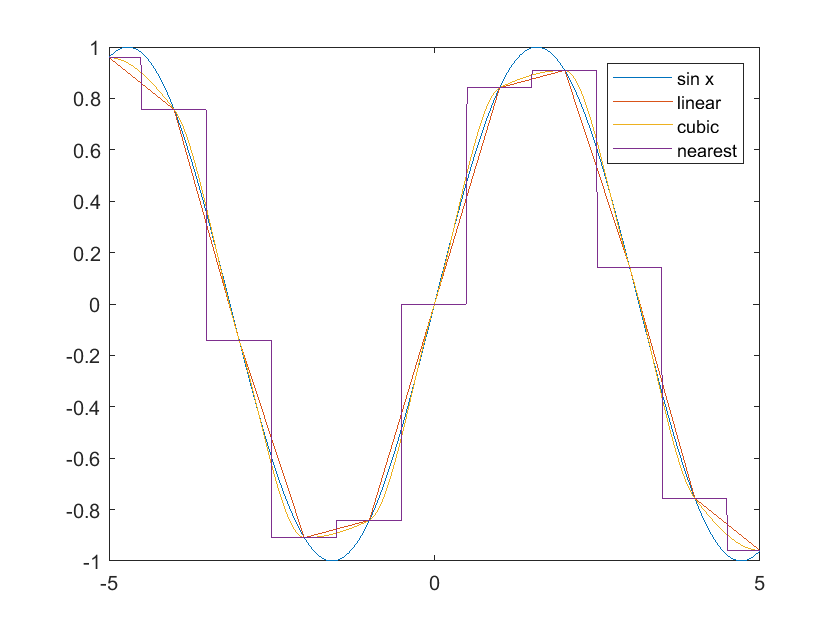

In [36]:
% 1. Sine Function
x = -5 : 1 : 5;                         % Known data points
v = sin(x);                            % Known data values  
xq = -5 : 0.01 : 5;                     % Query points

% Different methods of interpolation
vq_lin = interp1(x,v,xq,'linear');
vq_cubic = interp1(x,v,xq,'pchip');
vq_nearest = interp1(x,v,xq,'nearest');

% True solution
vq_true = sin(xq);

% Plot results
figure(1)
plot(xq,vq_true,xq,vq_lin,xq,vq_cubic,xq,vq_nearest)
legend('sin x','linear','cubic','nearest')


With a finer grid, we get better result.

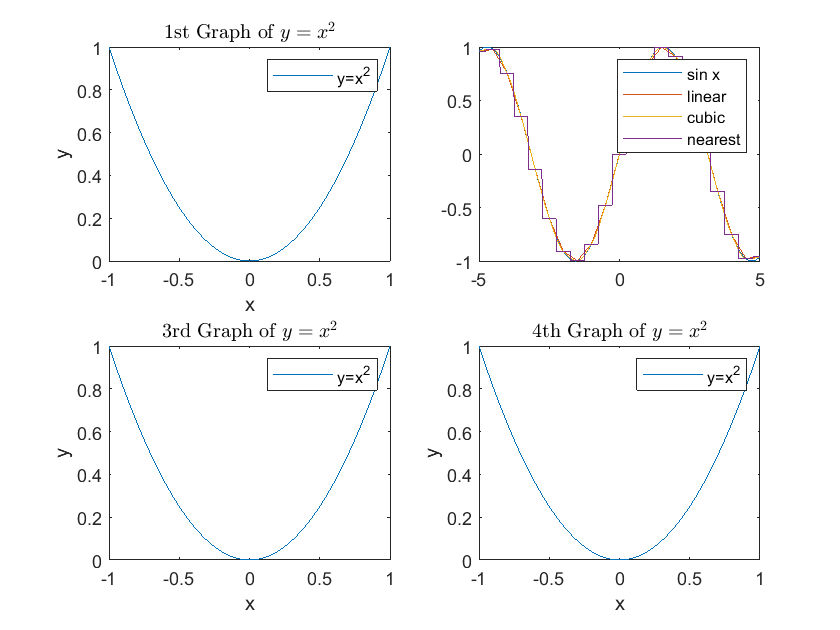

In [37]:
% 2. Sine Function with a finer grid
x1 = -5 : 0.5 : 5;                            % Known data points
y1 = sin(x1);                                 % Known data values
xint = -5 : 0.01 : 5;                         % Query points

% Repeating interpolation with the finer grid
yint_lin = interp1(x1,y1,xint,'linear');
yint_cubic = interp1(x1,y1,xint,'pchip');
yint_nearest = interp1(x1,y1,xint,'nearest');

% Exact solution
yint_sol = sin(xint);

% Plot results
figure(2)
plot(xint,yint_sol,xint,yint_lin,xint,yint_cubic,xint,yint_nearest)
legend('sin x','linear','cubic','nearest')

## griddedInterpolant

griddedInterpolant is used for n-dimensional interpolation on a grid. 

Compared with interp1, griddedInterpolant has two main differences.

    It can create a object, so is more flexible. 
    It can handle multi-dimensional data.

| Feature                    | interp1                         | griddedInterpolant           |
|----------------------------|---------------------------------|-------------------------------|
| **Dimensionality**         | One-dimensional                 | N-dimensional                 |
| **Input Structure**        | Two vectors (x, y)             | Grid vectors and grid data    |
| **Flexibility**            | Less flexible for repeated use  | More flexible, allows multiple evaluations |
| **Methods**                | Limited to specified methods     | Multiple methods including extrapolation |
| **Usage**                  | Simple function call            | Creates an object for interpolation |

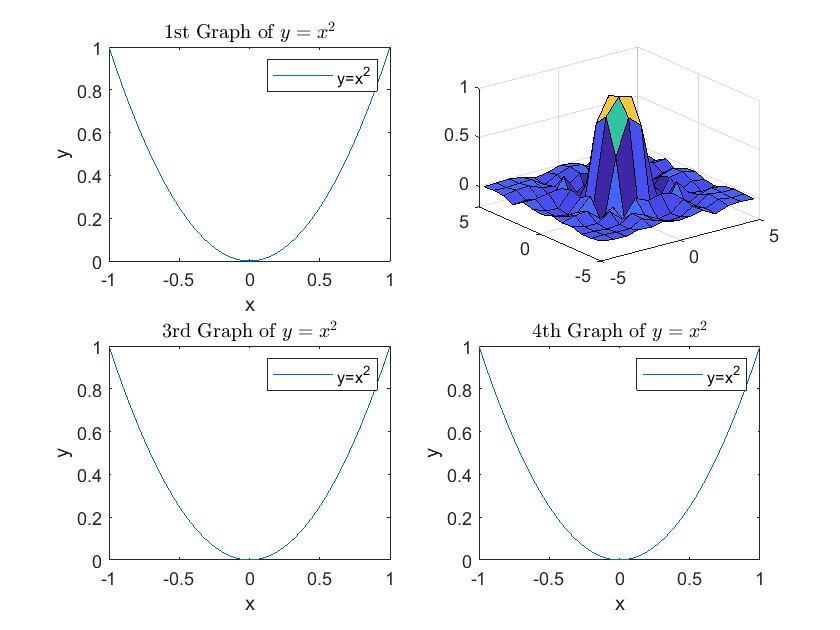

In [38]:
[x,y] = ndgrid(-5:0.8:5);               
% generates a grid of points in N-dimensional space
z = sin(x.^2 + y.^2) ./ (x.^2 + y.^2);
surf(x,y,z)                             
% creates a 3D surface plot

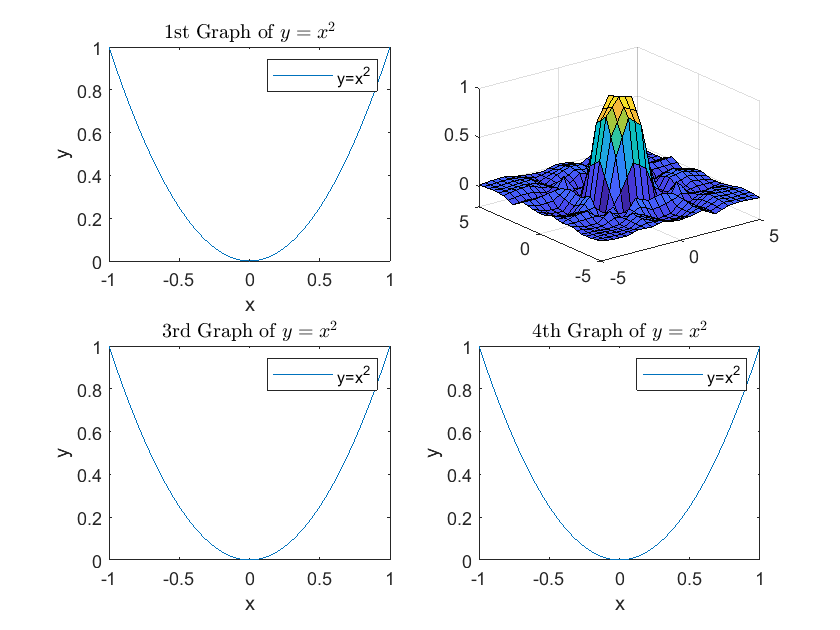

In [39]:
F = griddedInterpolant(x,y,z);  
% creates an interpolant object F from the input data x, y, and z
[xq,yq] = ndgrid(-5:0.4:5);    
% creates a new grid of points for querying the interpolant
vq = F(xq,yq);    
% uses the interpolant object F to compute interpolated values 
surf(xq,yq,vq)    
% creates a 3D surface plot 

From the example above, we can find that one distinction of griddedInterpolant is that, it creates an object, the "F" in example above.

So, people may prefer **griddedInterpolant** over **interp1** even in 1-dimension case, due to its object characteristic.  

___________________________________________________________________________________________________________________________________________

# 8. Discretization

___________________________________________________________________________________________________________________________________

## 8.1 Markov Chain Approximation of Continuous Stochastic Process

The Rouwenhorst and Tauchen methods are both techniques to approximate continuous stochastic processes, particularly for Markov processes

| Feature                   | Rouwenhorst Method                     | Tauchen Method                       |
|---------------------------|----------------------------------------|--------------------------------------|
| **Origin**                | Rouwenhorst (1995)                    | Tauchen (1986)                       |
| **Focus**                 | highly persistent processes ($\rho$ > 0.9)            | Primarily AR(1) processes            |

Here is a rouwenhorst example provided by professor Benjamin Moll.

In [40]:
%%file rouwenhorst.m

function [grid, trans, dist] = rouwenhorst(n, mu, sigma, rho)

    % Inputs:
    % n: Number of discrete states.
    % mu: Mean of the underlying continuous process.
    % sigma: Standard deviation of the underlying continuous process.
    % rho: Autocorrelation coefficient of the process.
    
    % Outputs:
    % grid: A vector containing the discrete points.
    % trans: The transition matrix that describes the probabilities of moving between states.
    % dist: The ergodic distribution of the Markov chain.

    % grid
    width = sqrt((n-1) * sigma^2 / ( 1 - rho^2));
    grid = linspace( mu-width, mu + width, n)';
    
    %transition matrix
    p0 = (1 + rho) / 2;
    trans = [p0 1-p0; 1-p0 p0];
    
    if n > 2
        for i = 1:n-2
            cstr_temp = zeros(length(trans(:,1)), 1);
            trans = p0 .* [trans cstr_temp; cstr_temp.' 0] + (1 - p0 ) .* [cstr_temp trans; cstr_temp.' 0]  + (1 - p0 ) .*  [ cstr_temp.' 0; trans cstr_temp] + p0 .* [ cstr_temp.' 0; cstr_temp trans];
        end
        trans = bsxfun(@rdivide, trans, sum(trans,2));
    end
    
    % ergodic distribution
    dist = ones(1,n)./n;
    for i = 1: 100
        dist = dist*(trans^i);
    end
    dist = dist';
end

File rouwenhorst.m created successfully.

In [41]:
n = 3;
mu = 0;
sigma = 1;
rho = 0.9;
[grid, trans, dist] = rouwenhorst(n, mu, sigma, rho)

grid = 3×1 double
   -3.2444
         0
    3.2444

trans = 3×3 double
    0.9025    0.0950    0.0025
    0.0475    0.9050    0.0475
    0.0025    0.0950    0.9025

dist = 3×1 double
    0.2500
    0.5000
    0.2500

## 8.2 Discrete normal distribution

Sometimes, we need to approximates a normal distribution using discrete points. Here is a function written by Professor Greg Kaplan. The function computes the probabilities for discrete points, and calculates the expected value and standard deviation. 

This can be useful where a continuous distribution needs to be handled in a discrete manner

In [42]:
%%file discrete_normal.m

function [f,x,p] = discrete_normal(n,mu,sigma,width)
% creates equally spaced approximation to normal distribution
% n is number of points
% mu is mean
% sigma is standard deviation
% width is the multiple of stand deviation for the width of the grid
% f is the error in the approximation
% x gives the location of the points
% p is probabilities

x = linspace(mu-width*sigma,mu+width*sigma,n)';

if n==2
    p = 0.5.*ones(n,1);
elseif n>2    
    p  = zeros(n,1);
    p(1) = normcdf(x(1) + 0.5*(x(2)-x(1)),mu,sigma);
    for i = 2:n-1
        p(i) = normcdf(x(i) + 0.5*(x(i+1)-x(i)),mu,sigma) - normcdf(x(i) - 0.5*(x(i)-x(i-1)),mu,sigma);
    end
    p(n) = 1 - sum(p(1:n-1));
end

Ex = x'*p;
SDx = sqrt((x'.^2)*p - Ex.^2);

f = SDx-sigma;

File discrete_normal.m created successfully.

In [43]:
n = 9; 
mu = 0;
sigma = 2;
width = 5;
[f,x,p] = discrete_normal(n,mu,sigma,width)

f = 0.1262

x = 9×1 double
  -10.0000
   -7.5000
   -5.0000
   -2.5000
         0
    2.5000
    5.0000
    7.5000
   10.0000

p = 9×1 double
    0.0000
    0.0009
    0.0295
    0.2356
    0.4680
    0.2356
    0.0295
    0.0009
    0.0000

___________________________________________________________________________________________________________________________________________

# 9. Simulation

________________________________________________________________________________________________________________________________________

## 9.1 Random Number Generation

By setting a specific seed value (in this case, 100), we ensure that the sequence of random numbers generated is the same every time we run the code..

In [44]:
rng(100)   % Set a random seed

**"rand"** generates uniformly distributed random numbers in the interval (0, 1).

The basic syntax is  

    rand generates a single random number
    rand(n) generates an n×n matrix of random numbers.
    rand(m, n) generates an m×n matrix of random numbers.

In [45]:
r1 = rand;           % Single random number
r2 = rand(3);       % 3x3 matrix of random numbers
r3 = rand(2, 4);    % 2x4 matrix of random numbers
r1
r2
r3

r1 = 0.5434

r2 = 3×3 double
    0.2784    0.0047    0.8259
    0.4245    0.1216    0.1367
    0.8448    0.6707    0.5751

r3 = 2×4 double
    0.8913    0.1853    0.2197    0.8117
    0.2092    0.1084    0.9786    0.1719

**"random"** is a more general function that generates random numbers from various probability distributions, such as normal, binomial, Poisson, etc.

The syntax depends on the distribution you want to use. For example:

    random('Normal', mu, sigma, m, n) 

generates an m×n matrix of random numbers from a normal distribution with mean mu and standard deviation sigma.

Generate a 3 by 2 matrix of random number.

In [46]:
rng(100)                              % Set a random seed
m = 3;                                % Number of rows
n = 2;                                % Number of columns

Matrix_Normal = random('Normal',0,1,m,n); 
Matrix_Normal
% generates a 3x2 matrix named Matrix_Normal filled with random numbers 
% drawn from a normal distribution.
% 0: The mean of the normal distribution.
% 1: The standard deviation of the normal distribution.

Matrix_Uniform = random('Uniform',0,1,m,n);
Matrix_Uniform
% generates a 3x2 matrix named Matrix_Uniform filled with random numbers 
% drawn from a uniform distribution.
% 0: The lower bound of the uniform distribution.
% 1: The upper bound of the uniform distribution.

Matrix_Normal = 3×2 double
    0.1609    0.6150
   -0.6151   -0.9014
   -0.2390    0.3481

Matrix_Uniform = 3×2 double
    0.8259    0.8913
    0.1367    0.2092
    0.5751    0.1853

Generate a 2 by 1 joint normal random vector with mean mu and variance omega.a

In [47]:
rng(100);   
mu = [2;-1];                          % Define the mean vector
omega = [2,3;3,5];                    % Define the covariance matrix
P = chol(omega)';                     % Perform Cholesky decomposition
B1 = P*random('Normal',0,1,2,1) + mu; % Generate a joint normal random vector
B1

B1 = 2×1 double
    2.2276
   -1.0935

Or, we can use the "mvnrnd" function to achieve the same result

In [48]:
rng(100); 
B2 = mvnrnd(mu,omega,1)';
B2

B2 = 2×1 double
    2.2276
   -1.0935

Generate a uniform distributed random number on interval [a,b]

In [49]:
a=1;
b=2;
C1 = random('Uniform',0,1)*(b-a) + a;

Here is another way, which is pretty similar. 

In [50]:
C2 = random('Uniform',a,b);

___________________________________________________________________________________________________________________________________________

# 10. Reference

______________________________________________________________________________________________________________________________________

1. MATLAB Help Center, https://ww2.mathworks.cn/help/matlab/index.html.